# Notebook 3 -- Climate Data Download and Feature Engineering

**Goal:** add weather covariates to the crop-yield table.

The ideal climate source for this Nigerian project is NiMet station data. Because historical NiMet station data can require permission or formal request, this repository also supports a public fallback: NASA POWER daily agroclimatology at state centroids, which was our preferred option dur to it's availability.

This notebook is structured to run either path:

- **NiMet path:** place your authorized CSV at `data/raw/climate/nimet_daily_station_observations.csv`.
- **NASA POWER path:** set `DOWNLOAD_NASA_POWER = True` and download daily climate variables for all states.

The output is a state-level climate feature table that can be joined to state × crop × season yield observations.

In [1]:
# Core scientific stack
from pathlib import Path
import sys
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Resolve project root whether the notebook is run from /notebooks or from the repository root.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"
MODELS_DIR = PROJECT_ROOT / "models"

for folder in [INTERIM_DIR, PROCESSED_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

RANDOM_STATE = 42


def print_section(title: str):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)

# Notebook-aware figure saving -------------------------------------------------
# Every plot generated in this notebook is saved under reports/figures/.
# The counter prevents overwriting plots produced inside loops.
import re

NOTEBOOK_ID = "03_climate_data_download_and_feature_engineering"
_FIGURE_SAVE_COUNTER = 1


def _safe_filename(text: str) -> str:
    text = str(text).strip().lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return text.strip("_") or "figure"


def save_figure(fig, name: str = "figure", dpi: int = 180):
    """Save a matplotlib figure to reports/figures with a notebook-specific name."""
    global _FIGURE_SAVE_COUNTER
    filename = f"{NOTEBOOK_ID}_{_FIGURE_SAVE_COUNTER:02d}_{_safe_filename(name)}.png"
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {path.relative_to(PROJECT_ROOT)}")
    _FIGURE_SAVE_COUNTER += 1
    return path


## 3.1 Loading state metadata and defining climate paths

In [2]:
from nigeria_crop_yield.data.climate import download_power_for_states, summarize_daily_climate, load_nimet_csv

STATE_META_CSV = PROCESSED_DIR / "state_metadata.csv"
NIMET_CSV = RAW_DIR / "climate" / "nimet_daily_station_observations.csv"
NASA_POWER_DAILY_CSV = RAW_DIR / "climate" / "nasa_power_daily_state_centroids_2022_2023.csv"
CLIMATE_FEATURES_CSV = INTERIM_DIR / "climate_features_state_2022_2023.csv"

state_meta = pd.read_csv(STATE_META_CSV)
display(state_meta.head())
print("Number of state centroids:", len(state_meta))

,state,geopolitical_zone,agroecological_zone,latitude,longitude
0,Abia,South East,Derived Savannah / Humid Forest Transition,5.45,7.52
1,Adamawa,North East,Northern Guinea Savannah,9.33,12.50
2,Akwa Ibom,South South,Humid Forest / Mangrove,5.02,7.92
3,Anambra,South East,Derived Savannah / Humid Forest Transition,6.22,6.94
4,Bauchi,North East,Sudan Savannah,10.31,9.84


Number of state centroids: 37


## 3.2 Choosing the climate source

There are two sources include in the imported python script ("nasa_power" and "nimet" datasets). So the part is where we choose the data source.
Default behavior of the code block is conservative: it will not automatically hit the API until you set `DOWNLOAD_NASA_POWER = True`. This keeps the notebook safe to open and inspect, while still giving you executable code for real climate download.

In [3]:
CLIMATE_SOURCE = "nasa_power"  # "nasa_power" or "nimet" (I choose nasa_power because it's easy to access and has good coverage)
DOWNLOAD_NASA_POWER = True     #  To download all states. To download only missing states, set to False.

START_DATE = "2022-01-01"
END_DATE = "2023-12-31"

NASA_POWER_PARAMETERS = [
    "T2M",               # mean temperature at 2m, deg C
    "T2M_MAX",           # maximum temperature at 2m, deg C
    "T2M_MIN",           # minimum temperature at 2m, deg C
    "PRECTOTCORR",       # precipitation, mm/day
    "RH2M",              # relative humidity at 2m, %
    "WS2M",              # wind speed at 2m
    "ALLSKY_SFC_SW_DWN", # all-sky surface shortwave radiation
]

print("Climate source:", CLIMATE_SOURCE)
print("NiMet CSV exists:", NIMET_CSV.exists())
print("NASA POWER daily CSV exists:", NASA_POWER_DAILY_CSV.exists())

Climate source: nasa_power
NiMet CSV exists: False
NASA POWER daily CSV exists: False


## 3.3 Downloading and loading daily climate observations

The download can take several minutes because it loops over all Nigerian state centroids.

In [4]:
climate_daily = None

if CLIMATE_SOURCE == "nimet":
    if not NIMET_CSV.exists():
        raise FileNotFoundError(
            f"NiMet file not found at {NIMET_CSV}. Place your authorized NiMet CSV there or switch CLIMATE_SOURCE to 'nasa_power'."
        )
    climate_daily = load_nimet_csv(NIMET_CSV)

elif CLIMATE_SOURCE == "nasa_power":
    if DOWNLOAD_NASA_POWER:
        climate_daily = download_power_for_states(
            state_metadata=state_meta,
            start_date=START_DATE,
            end_date=END_DATE,
            parameters=NASA_POWER_PARAMETERS,
            output_path=NASA_POWER_DAILY_CSV,
        )
    elif NASA_POWER_DAILY_CSV.exists():
        climate_daily = pd.read_csv(NASA_POWER_DAILY_CSV)
    else:
        print(
            "No NASA POWER climate file exists yet. Set DOWNLOAD_NASA_POWER=True and rerun this cell, "
            "or place a NiMet CSV under data/raw/climate/."
        )
else:
    raise ValueError("CLIMATE_SOURCE must be either 'nasa_power' or 'nimet'.")

if climate_daily is not None:
    print(climate_daily.shape)
    display(climate_daily.head())
    display(climate_daily.tail())

(27010, 11)


,state,latitude,longitude,date,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M,ALLSKY_SFC_SW_DWN
0,Abia,5.45,7.52,2022-01-01,26.66,31.14,22.38,4.33,78.87,0.67,16.14
1,Abia,5.45,7.52,2022-01-02,24.66,31.12,19.95,0.48,69.34,1.76,18.26
2,Abia,5.45,7.52,2022-01-03,22.76,29.42,18.14,1.55,67.53,2.19,20.11
3,Abia,5.45,7.52,2022-01-04,23.75,29.80,18.31,0.03,74.58,1.74,15.14
4,Abia,5.45,7.52,2022-01-05,25.03,30.34,20.28,0.01,71.70,1.33,19.32


,state,latitude,longitude,date,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M,ALLSKY_SFC_SW_DWN
27005,Zamfara,12.17,6.66,2023-12-27,20.29,30.21,12.45,0.0,22.61,3.55,19.33
27006,Zamfara,12.17,6.66,2023-12-28,21.37,31.82,13.35,0.0,23.28,3.36,19.60
27007,Zamfara,12.17,6.66,2023-12-29,21.79,32.15,13.90,0.0,24.62,3.03,20.17
27008,Zamfara,12.17,6.66,2023-12-30,22.85,33.05,15.04,0.0,25.06,3.29,19.71
27009,Zamfara,12.17,6.66,2023-12-31,23.32,33.49,15.20,0.0,24.23,3.39,20.36


## 3.4 Validating climate coverage

This check makes sure the climate file covers the same state names used in the NBS yield table.

In [5]:
if climate_daily is not None:
    climate_daily["date"] = pd.to_datetime(climate_daily["date"])
    coverage = (
        climate_daily.groupby("state", as_index=False)
        .agg(
            first_date=("date", "min"),
            last_date=("date", "max"),
            n_days=("date", "nunique"),
        )
        .sort_values("state")
    )
    display(coverage.head(20))
    print("States in climate file:", coverage["state"].nunique())
    print("Expected states:", state_meta["state"].nunique())
else:
    print("Climate file not loaded yet.")

,state,first_date,last_date,n_days
0,Abia,2022-01-01,2023-12-31,730
1,Adamawa,2022-01-01,2023-12-31,730
2,Akwa Ibom,2022-01-01,2023-12-31,730
3,Anambra,2022-01-01,2023-12-31,730
4,Bauchi,2022-01-01,2023-12-31,730
5,Bayelsa,2022-01-01,2023-12-31,730
6,Benue,2022-01-01,2023-12-31,730
7,Borno,2022-01-01,2023-12-31,730
8,Cross River,2022-01-01,2023-12-31,730
9,Delta,2022-01-01,2023-12-31,730


States in climate file: 37
Expected states: 37


## 3.5 Aggregating daily weather into growing-season features

The baseline implementation aggregates daily weather by state. A more advanced version can use crop-specific calendars and phenology windows.

In [6]:
if climate_daily is not None:
    climate_features = summarize_daily_climate(climate_daily)
    climate_features.to_csv(CLIMATE_FEATURES_CSV, index=False)
    print("Saved:", CLIMATE_FEATURES_CSV)
    display(climate_features.head())
    display(climate_features.describe().T)
else:
    climate_features = pd.DataFrame()
    print("Skipping feature aggregation because climate_daily is not loaded.")

Saved: c:\Users\Peter\Documents\projects\SHORT PROJECTS\ml-projects\crop-yield-nigeria-geoai\data\interim\climate_features_state_2022_2023.csv


,state,total_rainfall_mm,mean_tmean_c,mean_tmax_c,mean_tmin_c,mean_rh_percent,mean_wind_speed_m_s,growing_degree_days,heat_stress_days,mean_solar_radiation_kwh_m2_day,total_solar_radiation_kwh_m2
0,Abia,3055.27,25.785534,29.686096,22.620548,85.303466,1.427699,11523.44,0.0,16.495205,12041.50
1,Adamawa,1692.19,28.317411,34.919301,22.417397,52.593356,2.002890,13371.71,348.0,20.428945,14913.13
2,Akwa Ibom,5804.16,26.224466,29.489493,23.695082,86.831712,1.479986,11843.86,0.0,16.495205,12041.50
3,Anambra,3136.37,25.772192,29.605342,22.527000,84.236082,1.635479,11513.70,0.0,16.672918,12171.23
4,Bauchi,2890.11,25.006616,31.749658,19.222671,58.440726,2.029384,10954.83,154.0,20.584082,15026.38


,count,mean,std,min,25%,50%,75%,max
total_rainfall_mm,37.0,3000.083784,1339.649521,819.770000,1946.380000,2904.550000,3507.180000,7419.520000
mean_tmean_c,37.0,25.989165,1.018204,23.226521,25.505274,25.912781,26.338904,28.697521
mean_tmax_c,37.0,31.255389,2.135304,28.467904,29.489493,30.576644,32.625877,36.331575
mean_tmin_c,37.0,21.620993,1.409882,18.370164,20.767493,21.796781,22.620548,24.831384
mean_rh_percent,37.0,71.025029,15.914536,38.594205,57.970795,75.860397,85.303466,88.733849
mean_wind_speed_m_s,37.0,1.674481,0.581955,0.381630,1.318027,1.655548,2.138726,2.727384
growing_degree_days,37.0,11672.090541,743.289209,9655.360000,11318.850000,11616.330000,11927.400000,13649.190000
heat_stress_days,37.0,112.270270,142.189554,0.000000,0.000000,16.000000,206.000000,463.000000
mean_solar_radiation_kwh_m2_day,37.0,18.413953,1.999143,15.312822,16.672164,18.085219,20.564822,21.729603
total_solar_radiation_kwh_m2,37.0,13442.185946,1459.374266,11178.360000,12170.680000,13202.210000,15012.320000,15862.610000


## 3.6 Visualizing climate gradients across states

These plots help to verify that the climate features make agronomic sense before joining them into the ML dataset.

Saved figure: reports\figures\03_climate_data_download_and_feature_engineering_01_figure_01.png


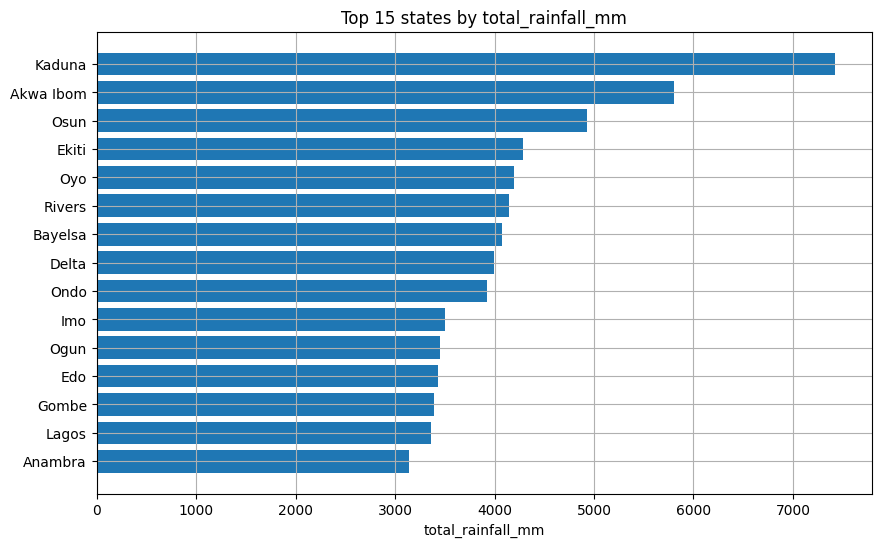

Saved figure: reports\figures\03_climate_data_download_and_feature_engineering_02_figure_01.png


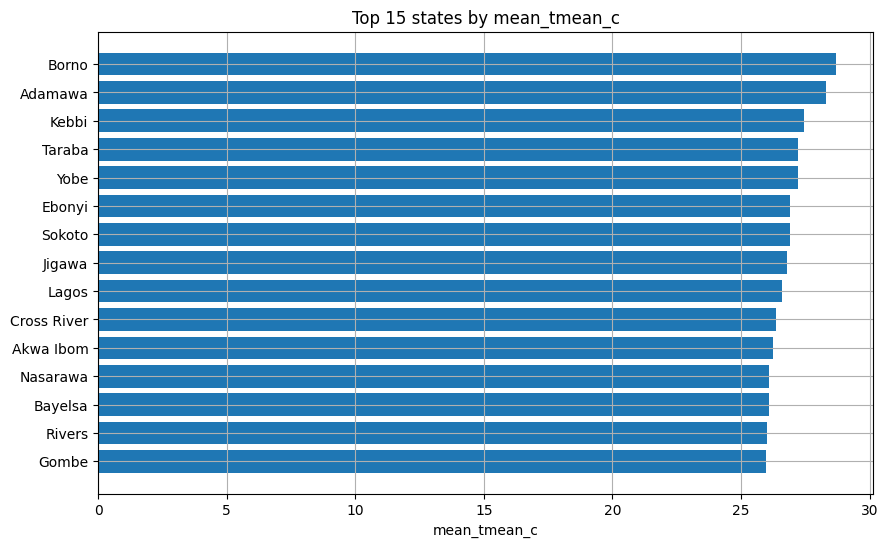

Saved figure: reports\figures\03_climate_data_download_and_feature_engineering_03_figure_01.png


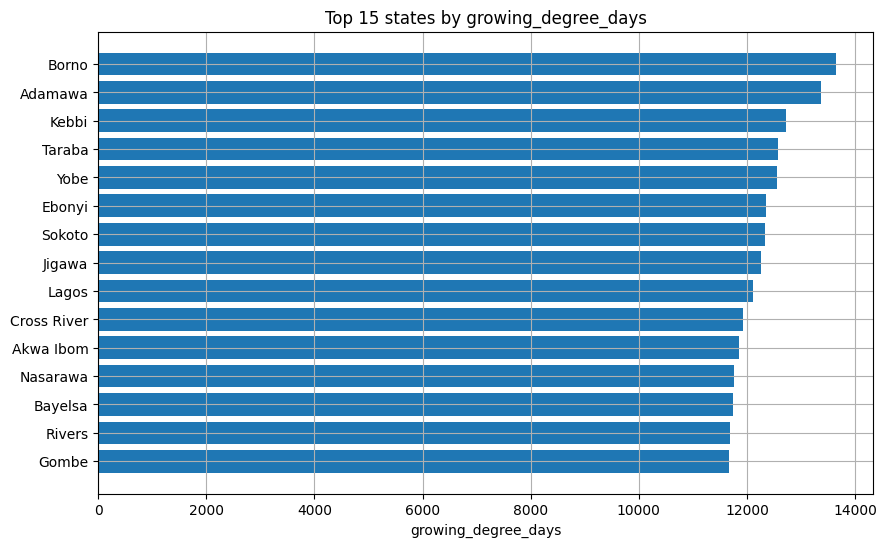

Saved figure: reports\figures\03_climate_data_download_and_feature_engineering_04_figure_01.png


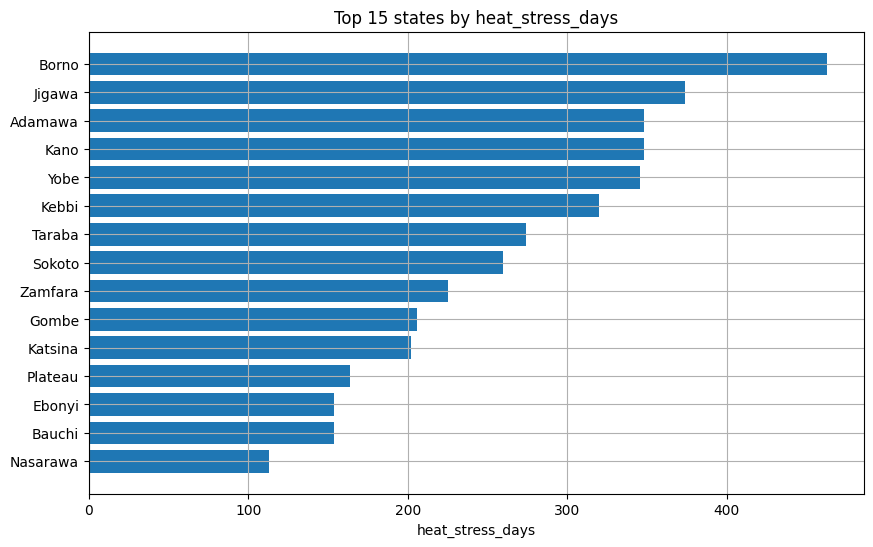

In [7]:
if not climate_features.empty:
    plot_cols = ["total_rainfall_mm", "mean_tmean_c", "growing_degree_days", "heat_stress_days"]
    for col in plot_cols:
        if col not in climate_features.columns:
            continue
        plot_df = climate_features.sort_values(col).tail(15)
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.barh(plot_df["state"], plot_df[col])
        ax.set_xlabel(col)
        ax.set_title(f"Top 15 states by {col}")
        save_figure(fig, "figure_01")
        plt.show()
else:
    print("No climate features to plot yet.")

## 3.7 Merging climate features into the NBS yield table

This creates an interim dataset. The final modeling dataset is built in Notebook 5 after leakage control and optional Sentinel-2 features are also handled.

In [8]:
NBS_CSV = PROCESSED_DIR / "nbs_crop_yield_state_zone_2022_2023.csv"
nbs = pd.read_csv(NBS_CSV)
base = (
    nbs[~nbs["is_aggregate"].astype(bool)]
    .query("yield_kg_ha.notna()")
    .merge(state_meta, on="state", how="left")
    .copy()
)
base["log_planted_area_ha"] = np.log1p(base["planted_area_ha"].clip(lower=0))

if not climate_features.empty:
    nbs_climate = base.merge(climate_features, on="state", how="left")
else:
    nbs_climate = base.copy()

OUT = INTERIM_DIR / "nbs_with_climate_features.csv"
nbs_climate.to_csv(OUT, index=False)
print("Saved:", OUT)
print(nbs_climate.shape)
display(nbs_climate.head())

Saved: c:\Users\Peter\Documents\projects\SHORT PROJECTS\ml-projects\crop-yield-nigeria-geoai\data\interim\nbs_with_climate_features.csv
(490, 27)


,season,zone,state,crop,households_reporting_000,planted_area_ha,harvested_area_ha,harvested_quantity_kg,yield_kg_ha,is_aggregate,source_sheet,source_table,geopolitical_zone,agroecological_zone,latitude,longitude,log_planted_area_ha,total_rainfall_mm,mean_tmean_c,mean_tmax_c,mean_tmin_c,mean_rh_percent,mean_wind_speed_m_s,growing_degree_days,heat_stress_days,mean_solar_radiation_kwh_m2_day,total_solar_radiation_kwh_m2
0,major,North Central,Benue,MAIZE,850.39,367795.171270,350398.700331,3.939929e+08,1124.413179,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...,North Central,Southern Guinea Savannah,7.34,8.74,12.815284,2791.10,25.855397,30.575918,21.825959,75.860397,1.950466,11574.44,2.0,18.280082,13344.46
1,major,North Central,FCT,MAIZE,266.34,153246.079216,123737.798835,1.606178e+08,1298.049753,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...,North Central,Southern Guinea Savannah,9.08,7.40,11.939807,2791.66,25.271973,31.020178,20.592260,71.285904,1.552260,11148.54,94.0,19.003315,13872.42
2,major,North Central,Kogi,MAIZE,640.86,327793.065371,309235.626289,4.257146e+08,1376.667527,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...,North Central,Southern Guinea Savannah,7.80,6.74,12.700141,2922.19,25.946644,30.472301,21.926014,77.683192,1.599945,11641.05,2.0,17.665493,12895.81
3,major,North Central,Kwara,MAIZE,398.11,307483.872742,301489.864767,5.002011e+08,1659.097522,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...,North Central,Southern Guinea Savannah,8.50,4.55,12.636181,3120.12,25.177890,30.194986,21.067233,78.085986,1.852548,11079.86,11.0,18.085219,13202.21
4,major,North Central,Nasarawa,MAIZE,520.48,416547.122485,360177.787028,4.213675e+08,1169.887511,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...,North Central,Southern Guinea Savannah,8.54,8.32,12.939757,2904.55,26.104479,31.606562,21.643397,71.356986,1.675493,11756.27,113.0,18.834699,13749.33


## 3.8 Climate-target correlation screen

This is a quick diagnostic to see whether climate variables contain signal for prediction.

,yield_kg_ha
mean_tmax_c,-0.321524
heat_stress_days,-0.284437
mean_wind_speed_m_s,-0.203523
mean_tmean_c,-0.166438
growing_degree_days,-0.166438
mean_tmin_c,0.212112
total_rainfall_mm,0.215805
mean_rh_percent,0.333826
yield_kg_ha,1.000000


Saved figure: reports\figures\03_climate_data_download_and_feature_engineering_05_figure_02.png


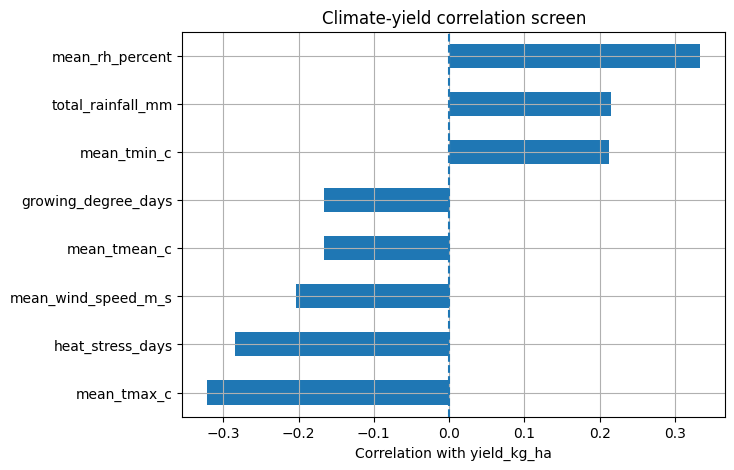

In [9]:
climate_cols = [
    "total_rainfall_mm", "mean_tmean_c", "mean_tmax_c", "mean_tmin_c",
    "mean_rh_percent", "mean_wind_speed_m_s", "growing_degree_days", "heat_stress_days",
]
available_climate_cols = [c for c in climate_cols if c in nbs_climate.columns]

if available_climate_cols:
    corr = nbs_climate[["yield_kg_ha"] + available_climate_cols].corr(numeric_only=True)[["yield_kg_ha"]].sort_values("yield_kg_ha")
    display(corr)

    fig, ax = plt.subplots(figsize=(7, 5))
    corr.drop(index="yield_kg_ha").plot(kind="barh", legend=False, ax=ax)
    ax.axvline(0, linestyle="--")
    ax.set_xlabel("Correlation with yield_kg_ha")
    ax.set_title("Climate-yield correlation screen")
    save_figure(fig, "figure_02")
    plt.show()
else:
    print("No climate variables available yet. Download climate data first.")